In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pointbiserialr
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [48]:
plt.rcParams['font.sans-serif'] = ['STKaiti']  # 设置中文字体为楷体
plt.rcParams['axes.unicode_minus'] = False

In [49]:
df = pd.read_excel('./campusBicyclesharingdataset.xlsx')

In [50]:
correct_columns = ['车辆分布合理性A', '高峰期可用率B', '动态调度车辆能力E1', 
                   '故障处理效率E2', '恶劣天气抗干扰性E3', '校园出行服务稳定性E4',
                   '车辆周转率F1', '寻车时间中位数F2', '热点区域供需比F3', '车辆的平均使用时长F4']

In [51]:
df.columns = correct_columns

1. 数据预处理与探索：读取 campus-Bicycle-sharing-dataset.xlsx 数据集，将所有分类变量（如“高/低”）转换为数值（“高” → 1，“低” → 0）。统计连续变量 F1–F4 的分布特征（如均值、标准差、分位数）用表格显示，并绘制其直方图或箱线图，解释发现。

In [52]:
binary_cols = ['车辆分布合理性A', '高峰期可用率B', '动态调度车辆能力E1',
               '故障处理效率E2', '恶劣天气抗干扰性E3', '校园出行服务稳定性E4']
for col in binary_cols:
    df[col] = df[col].map({'高': 1, '低': 0})

In [53]:
continuous_cols = ['车辆周转率F1', '寻车时间中位数F2', '热点区域供需比F3', '车辆的平均使用时长F4']
stats = df[continuous_cols].describe(percentiles=[0.25, 0.5, 0.75]).T
stats['std'] = df[continuous_cols].std()
stats = stats[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]
print("\n连续变量描述统计表：")
print(stats.round(2))


连续变量描述统计表：
               mean    std   min     25%    50%     75%    max
车辆周转率F1       63.29  39.73   5.0   32.00   52.9   92.60  180.0
寻车时间中位数F2    250.35  87.68  71.0  170.75  274.0  323.00  396.0
热点区域供需比F3     65.92  13.23  32.0   57.75   67.0   75.00   91.0
车辆的平均使用时长F4   20.32   8.29   7.0   14.98   20.0   25.12   46.0


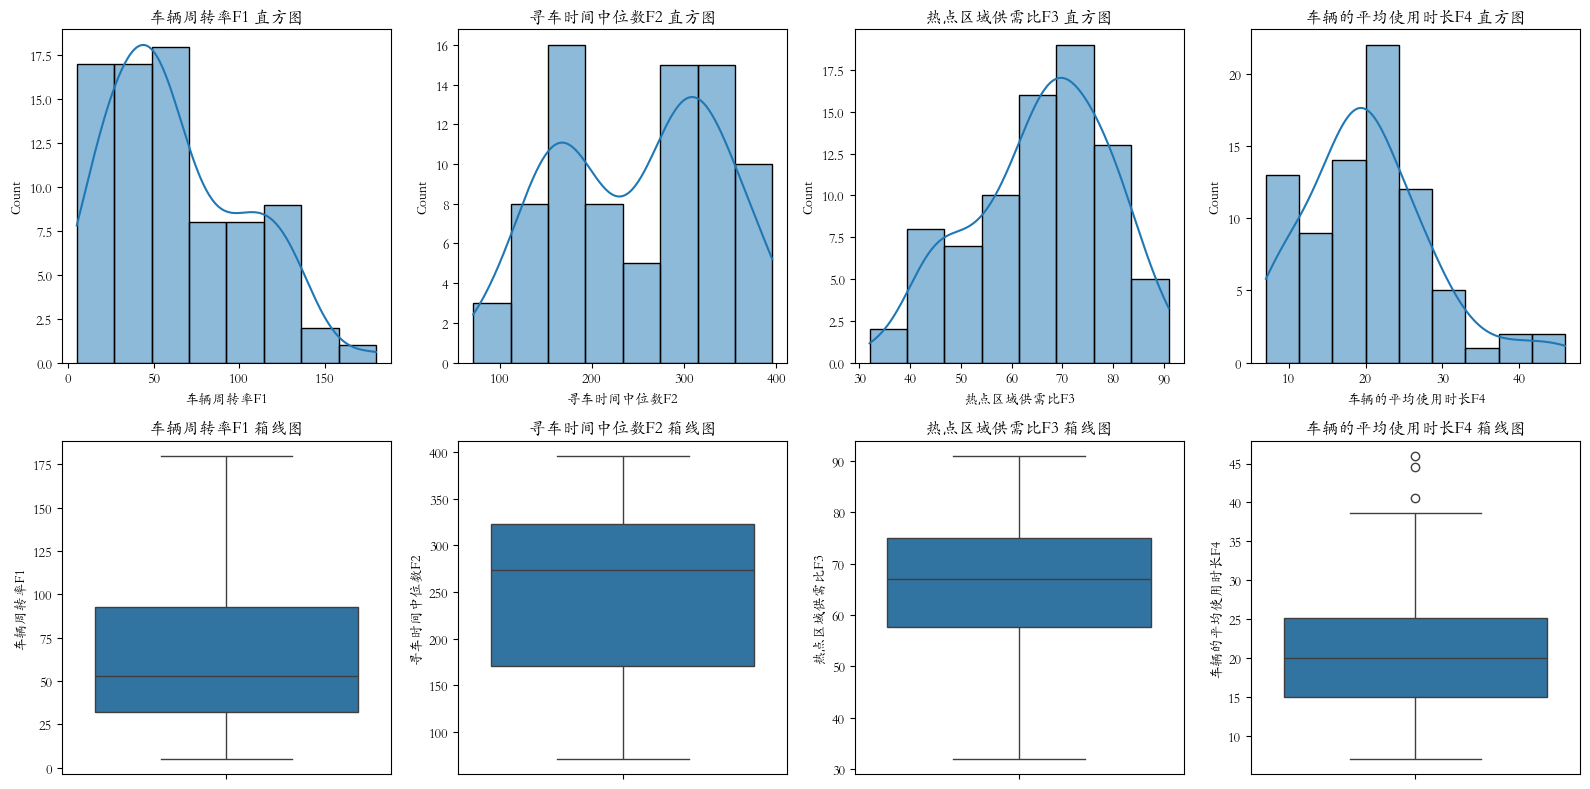

In [54]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, col in enumerate(continuous_cols):
    sns.histplot(df[col], kde=True, ax=axes[0, i])
    axes[0, i].set_title(f'{col} 直方图')
    sns.boxplot(y=df[col], ax=axes[1, i])
    axes[1, i].set_title(f'{col} 箱线图')
plt.tight_layout()
plt.show()

2. 多任务分类建模：以 F1–F4 为共同特征，同时预测调度响应能力（E1）故障处理效率（E2）与校园出行服务稳定性（E4）三个二分类目标变量。输出每个任务的分类报告（准确率、召回率、 F1 分数）及特征重要性热力图，分析哪些特征对三个任务有共同影响，哪些具有任务特异性m

In [55]:
X = df[continuous_cols]  # 特征：F1,F2,F3,F4
targets = ['动态调度车辆能力E1', '故障处理效率E2', '校园出行服务稳定性E4']
feature_importance = {}

for target in targets:
    y = df[target]
    # 划分训练集和测试集（80/20）
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    print(f"\n====== {target} 分类报告 ======")
    print(classification_report(y_test, y_pred, target_names=['低', '高']))
    feature_importance[target] = clf.feature_importances_


====== 动态调度车辆能力E1 分类报告 ======
              precision    recall  f1-score   support

           低       0.56      0.56      0.56         9
           高       0.43      0.43      0.43         7

    accuracy                           0.50        16
   macro avg       0.49      0.49      0.49        16
weighted avg       0.50      0.50      0.50        16


====== 故障处理效率E2 分类报告 ======
              precision    recall  f1-score   support

           低       1.00      0.50      0.67        10
           高       0.55      1.00      0.71         6

    accuracy                           0.69        16
   macro avg       0.77      0.75      0.69        16
weighted avg       0.83      0.69      0.68        16


====== 校园出行服务稳定性E4 分类报告 ======
              precision    recall  f1-score   support

           低       0.25      0.25      0.25         4
           高       0.75      0.75      0.75        12

    accuracy                           0.62        16
   macro avg       0.50      0.50   

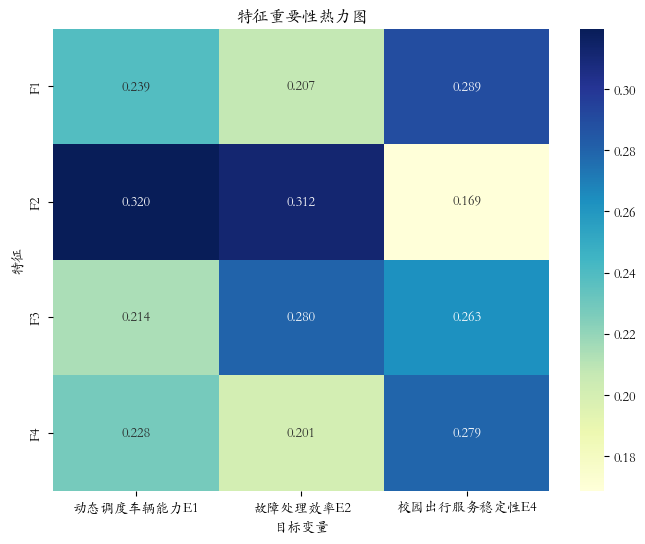

In [56]:
imp_df = pd.DataFrame(feature_importance, index=['F1', 'F2', 'F3', 'F4'])
plt.figure(figsize=(8, 6))
sns.heatmap(imp_df, annot=True, cmap='YlGnBu', fmt='.3f')
plt.title('特征重要性热力图')
plt.xlabel('目标变量')
plt.ylabel('特征')
plt.show()

3. 在校园共享单车的日常管理中，运营方通常认为提升动态调度能力（E1）能够缩短用户寻车时间（F2）。请基于所提供的数据，通过相关性探索分析判断该判断是否成立。若结果与经验认知有不一致，请从混杂变量出发给出可能的合理解释。

In [57]:
group_means = df.groupby('动态调度车辆能力E1')['寻车时间中位数F2'].mean()
print("\nE1=0 (低调度) 平均寻车时间:", group_means[0])
print("E1=1 (高调度) 平均寻车时间:", group_means[1])


E1=0 (低调度) 平均寻车时间: 262.2916666666667
E1=1 (高调度) 平均寻车时间: 232.4375


In [58]:
corr, p_value = pointbiserialr(df['动态调度车辆能力E1'], df['寻车时间中位数F2'])
print(f"点双列相关系数: {corr:.3f}, p-value: {p_value:.4f}")

点双列相关系数: -0.168, p-value: 0.1367


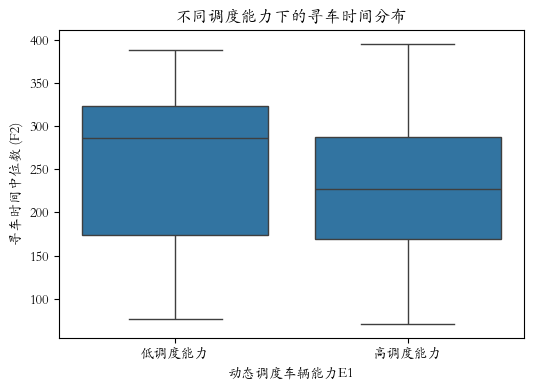

In [59]:
plt.figure(figsize=(6,4))
sns.boxplot(x='动态调度车辆能力E1', y='寻车时间中位数F2', data=df)
plt.xticks([0,1], ['低调度能力', '高调度能力'])
plt.ylabel('寻车时间中位数 (F2)')
plt.title('不同调度能力下的寻车时间分布')
plt.show()

**数据未能提供充分证据支持“提升动态调度能力（E1）能够显著缩短用户寻车时间（F2）”这一经验判断。虽然均值差异接近30秒（约11%的降幅），但统计上不显著，可能由随机波动或混杂因素导致。**